In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
!pip install -q pycocotools scipy

In [9]:
# Upload garment-panel-seg.zip as a Kaggle Dataset first (Add Input > New Dataset),
# then this finds and unzips it. Falls back to git clone if you pushed to GitHub.
import os, glob, zipfile, shutil

WORK = "/kaggle/working/garment-panel-seg"
if os.path.exists(WORK):
    shutil.rmtree(WORK)

zips = glob.glob("/kaggle/input/**/garment-panel-seg*.zip", recursive=True)
if zips:
    with zipfile.ZipFile(zips[0]) as z:
        z.extractall("/kaggle/working/")
    print("unzipped repo from", zips[0])
else:
    # fallback: replace with your GitHub URL once pushed
    !cd /kaggle/working && git clone https://github.com/Universalmike/garment-panel-seg.git
os.chdir(WORK)
print("cwd:", os.getcwd())
print(os.listdir("."))

shell-init: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory
chdir: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory
Cloning into 'garment-panel-seg'...
remote: Enumerating objects: 22, done.
remote: Counting objects: 100% (22/22), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 22 (delta 0), reused 22 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (22/22), 22.30 KiB | 22.30 MiB/s, done.
cwd: /kaggle/working/garment-panel-seg
['tests', 'src', 'predict.py', 'example_apply_fabric.py', 'DESIGN_NOTE.md', 'example_before.png', '.git', 'README.md', 'example_after.png', 'requirements.txt', 'weights', '.gitignore']


In [10]:
import glob, os, subprocess

# 1) look for full annotations already added as a Kaggle input
found = glob.glob("/kaggle/input/**/instances_attributes_*2020.json", recursive=True)

FP = "/kaggle/working/fp"
os.makedirs(FP, exist_ok=True)

if found:
    ANN = found[0]
    # find the image dir that goes with it: the folder holding the most jpgs
    cand = {}
    for p in glob.glob("/kaggle/input/**/*.jpg", recursive=True):
        d = os.path.dirname(p); cand[d] = cand.get(d, 0) + 1
    IMGS = max(cand, key=cand.get)
    print("using existing annotations:", ANN)
else:
    # official CVDF download (validation set: small + fast, has the apparel parts)
    ANN = f"{FP}/instances_attributes_val2020.json"
    print("downloading official Fashionpedia val set from CVDF...")
    !wget -q -O {ANN} https://s3.amazonaws.com/ifashionist-dataset/annotations/instances_attributes_val2020.json
    !wget -q -O {FP}/val_test2020.zip https://s3.amazonaws.com/ifashionist-dataset/images/val_test2020.zip
    !cd {FP} && unzip -q -o val_test2020.zip
    cand = {}
    for p in glob.glob(f"{FP}/**/*.jpg", recursive=True):
        d = os.path.dirname(p); cand[d] = cand.get(d, 0) + 1
    IMGS = max(cand, key=cand.get)

# ---- to use the FULL train set instead (better model, ~20GB+ download), swap the
#      two wget lines above for these and set ANN to the train json:
# https://s3.amazonaws.com/ifashionist-dataset/annotations/instances_attributes_train2020.json
# https://s3.amazonaws.com/ifashionist-dataset/images/train2020.zip

print("ANN :", ANN)
print("IMGS:", IMGS, "| jpg count:", cand[IMGS])

downloading official Fashionpedia val set from CVDF...
ANN : /kaggle/working/fp/instances_attributes_val2020.json
IMGS: /kaggle/working/fp/test | jpg count: 3200


In [8]:
import glob
print(glob.glob("/kaggle/working/**/src/prepare_data.py", recursive=True))

[]


In [11]:
!python -m src.prepare_data \
    --ann  "{ANN}" \
    --imgs "{IMGS}" \
    --out  /kaggle/working/data/train \
    --max-images 4000 --require-sleeve --seed 42

loading annotations...
category ids -> body:[0, 1, 2, 3, 4, 5, 9, 10, 11, 12] sleeve:[31] collar:[28]
100%|██████████████████████████████████████| 1158/1158 [00:10<00:00, 108.19it/s]
wrote 742 mask/image pairs -> /kaggle/working/data/train/manifest.json


In [12]:
!python -m src.train \
    --manifest /kaggle/working/data/train/manifest.json \
    --epochs 30 --size 256 --batch 16 --seed 42 \
    --out /kaggle/working/garment-panel-seg/weights/model.pt

device: cuda
train 631  val 111
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth
100%|███████████████████████████████████████| 13.6M/13.6M [00:00<00:00, 228MB/s]
trainable params 491,564  |  total inference params 2,303,276
epoch 01/30  loss 1.1548  val_mIoU 0.4370
  saved /kaggle/working/garment-panel-seg/weights/model.pt (val_mIoU 0.4370)
epoch 02/30  loss 0.7548  val_mIoU 0.4813
  saved /kaggle/working/garment-panel-seg/weights/model.pt (val_mIoU 0.4813)
epoch 03/30  loss 0.6800  val_mIoU 0.4863
  saved /kaggle/working/garment-panel-seg/weights/model.pt (val_mIoU 0.4863)
epoch 04/30  loss 0.6130  val_mIoU 0.5075
  saved /kaggle/working/garment-panel-seg/weights/model.pt (val_mIoU 0.5075)
epoch 05/30  loss 0.5727  val_mIoU 0.5378
  saved /kaggle/working/garment-panel-seg/weights/model.pt (val_mIoU 0.5378)
epoch 06/30  loss 0.5236  val_mIoU 0.5361
epoch 07/30  loss 0.5049  val_mIoU 0.5482
  sav

In [13]:
import os
w = "/kaggle/working/garment-panel-seg/weights/model.pt"
print("weights saved:", os.path.exists(w), "| size MB:",
      round(os.path.getsize(w)/1e6, 1) if os.path.exists(w) else "-")

# quick visual check on one val image
import glob
img = glob.glob(f"{IMGS}/*.jpg")[0]
!cd /kaggle/working/garment-panel-seg && python predict.py --image "{img}" --out /kaggle/working/pred_mask.png

weights saved: True | size MB: 9.5
wrote /kaggle/working/pred_mask.png
panels present: ['front_body', 'left_sleeve', 'right_sleeve']
latency: 372.7 ms/image on CPU (x86_64)


In [4]:
!pip install -q pycocotools scipy pytest

import os, shutil

os.chdir("/kaggle/working")                     # never rmtree the cwd
WORK = "/kaggle/working/garment-panel-seg"
if os.path.exists(WORK):
    shutil.rmtree(WORK)

!git clone -q https://github.com/Universalmike/garment-panel-seg.git
os.chdir(WORK)

print("cwd:", os.getcwd())
!git log --oneline -1

# Guards. If either of these is False you are running stale code: push and re-run.
print("src/evaluate.py present :", os.path.exists("src/evaluate.py"))
print("src/metrics.py present  :", os.path.exists("src/metrics.py"))
print("weights/model.pt present:", os.path.exists("weights/model.pt"),
      "|", round(os.path.getsize("weights/model.pt") / 1e6, 1) if os.path.exists("weights/model.pt") else "-", "MB")

assert os.path.exists("src/evaluate.py"), "stale clone - push your commits to GitHub first"
assert os.path.exists("weights/model.pt"), "checkpoint missing from the clone" 

cwd: /kaggle/working/garment-panel-seg
093d1f6 (HEAD -> main, origin/main, origin/HEAD) Add procedural synthetic garment renders and mixed training
src/evaluate.py present : True
src/metrics.py present  : True
weights/model.pt present: True | 9.5 MB


In [1]:
# Fashionpedia val2020. If you have attached it as a Kaggle input dataset this
# reuses it; otherwise it pulls from the official CVDF mirror (~1 GB, a few min).
import glob, os

found = glob.glob("/kaggle/input/**/instances_attributes_*2020.json", recursive=True)
FP = "/kaggle/working/fp"
os.makedirs(FP, exist_ok=True)

if found:
    ANN = found[0]
    print("using attached annotations:", ANN)
else:
    ANN = f"{FP}/instances_attributes_val2020.json"
    if not os.path.exists(ANN):
        !wget -q -O {ANN} https://s3.amazonaws.com/ifashionist-dataset/annotations/instances_attributes_val2020.json
    if not glob.glob(f"{FP}/**/*.jpg", recursive=True):
        !wget -q -O {FP}/val_test2020.zip https://s3.amazonaws.com/ifashionist-dataset/images/val_test2020.zip
        !cd {FP} && unzip -q -o val_test2020.zip

# the image folder is whichever directory holds the most jpgs
cand = {}
roots = ["/kaggle/input"] if found else [FP]
for root in roots:
    for jpg in glob.glob(f"{root}/**/*.jpg", recursive=True):
        d = os.path.dirname(jpg)
        cand[d] = cand.get(d, 0) + 1
IMGS = max(cand, key=cand.get)

print("ANN :", ANN)
print("IMGS:", IMGS, "| jpg count:", cand[IMGS])

ANN : /kaggle/working/fp/instances_attributes_val2020.json
IMGS: /kaggle/working/fp/test | jpg count: 3200


In [2]:
# Rebuild the exact same manifest the model was trained on. prepare_data shuffles
# with --seed, so seed 42 on the same annotation file reproduces the same 742
# pairs in the same order - which is what makes the val split below the genuine
# held-out set rather than images the model has already seen.
!python -m src.prepare_data \
    --ann  "{ANN}" \
    --imgs "{IMGS}" \
    --out  /kaggle/working/data/train \
    --max-images 4000 --require-sleeve --seed 42

/usr/bin/python3: Error while finding module specification for 'src.prepare_data' (ModuleNotFoundError: No module named 'src')


In [4]:
# Quick health check on the clone before trusting any numbers it produces.
!pytest -q


...................                                                      [100%]
19 passed in 7.95s


In [5]:
!python -m src.evaluate \
    --manifest /kaggle/working/data/train/manifest.json \
    --weights  weights/model.pt \
    --val-split 0.15 --seed 42 \
    --compare

scoring 111 images at 256px input, device cuda
no-tta: 100%|█████████████████████████████████| 111/111 [00:04<00:00, 25.47it/s]

--- flip TTA: off ---
per-class IoU (mean over images where the class is in ground truth):
  background   0.9627   (111 images)
  body         0.5993   (111 images)
  sleeve       0.5125   (111 images)
  collar       0.1669   (30 images)

mean per-class IoU, panels only  (the brief's metric) : 0.5188
mean per-class IoU, incl. background                  : 0.6550
tta: 100%|████████████████████████████████████| 111/111 [00:04<00:00, 24.62it/s]

--- flip TTA: on ---
per-class IoU (mean over images where the class is in ground truth):
  background   0.9634   (111 images)
  body         0.6134   (111 images)
  sleeve       0.5304   (111 images)
  collar       0.1606   (30 images)

mean per-class IoU, panels only  (the brief's metric) : 0.5330
mean per-class IoU, incl. background                  : 0.6648


In [5]:
# ~5 min on Kaggle for 2000 samples.
!python -m src.synth \
    --out  /kaggle/working/data/synth \
    --n    2000 \
    --size 384 \
    --seed 42 \
    --contact-sheet /kaggle/working/synth_sheet.png

synth: 100%|████████████████████████████████| 2000/2000 [09:57<00:00,  3.35it/s]
wrote 2000 pairs -> /kaggle/working/data/synth/manifest.json
  background  77.80% of pixels
  body        18.37% of pixels
  sleeve       3.15% of pixels
  collar       0.68% of pixels
contact sheet -> /kaggle/working/synth_sheet.png


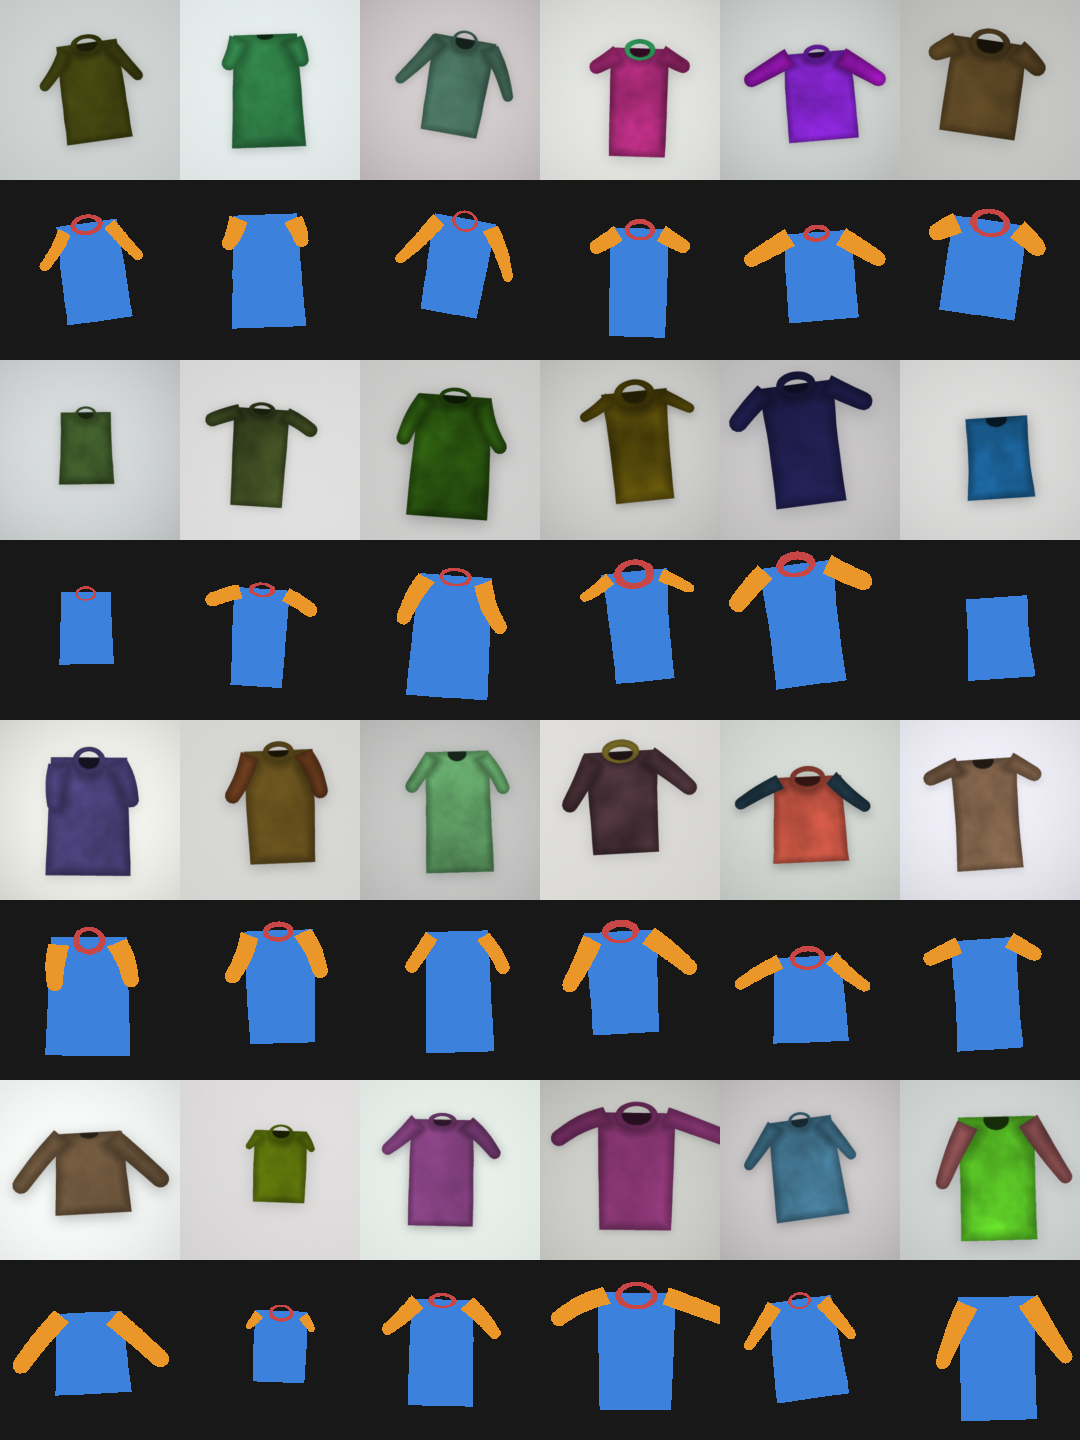

In [6]:
from IPython.display import Image as IPyImage
IPyImage("/kaggle/working/synth_sheet.png", width=950)

In [9]:
!python -m src.train \
    --manifest       /kaggle/working/data/train/manifest.json \
    --synth-manifest /kaggle/working/data/synth/manifest.json \
    --synth-frac 0.5 \
    --epochs 30 --size 256 --batch 16 --seed 42 \
    --out /kaggle/working/garment-panel-seg/weights/model_mixed.pt

device: cuda
train 631 real + 1000 synthetic (61% synthetic)  |  val 111 real only
trainable params 491,564  |  total inference params 2,303,276
epoch 01/30  loss 0.5635  val_mIoU(panels) 0.3668  val_mIoU(incl bg) 0.5442
  saved /kaggle/working/garment-panel-seg/weights/model_mixed.pt (val_mIoU 0.3668)
epoch 02/30  loss 0.2283  val_mIoU(panels) 0.4351  val_mIoU(incl bg) 0.5906
  saved /kaggle/working/garment-panel-seg/weights/model_mixed.pt (val_mIoU 0.4351)
epoch 03/30  loss 0.1849  val_mIoU(panels) 0.4635  val_mIoU(incl bg) 0.6143
  saved /kaggle/working/garment-panel-seg/weights/model_mixed.pt (val_mIoU 0.4635)
epoch 04/30  loss 0.1728  val_mIoU(panels) 0.4384  val_mIoU(incl bg) 0.5942
epoch 05/30  loss 0.1613  val_mIoU(panels) 0.4515  val_mIoU(incl bg) 0.6012
epoch 06/30  loss 0.1505  val_mIoU(panels) 0.4804  val_mIoU(incl bg) 0.6266
  saved /kaggle/working/garment-panel-seg/weights/model_mixed.pt (val_mIoU 0.4804)
epoch 07/30  loss 0.1375  val_mIoU(panels) 0.4867  val_mIoU(incl bg

In [11]:
print("=" * 30, "BASELINE (Fashionpedia only)", "=" * 30)
!python -m src.evaluate \
    --manifest /kaggle/working/data/train/manifest.json \
    --weights  weights/model.pt \
    --val-split 0.15 --seed 42

print()
print("=" * 30, "MIXED (Fashionpedia + synthetic)", "=" * 30)
!python -m src.evaluate \
    --manifest /kaggle/working/data/train/manifest.json \
    --weights  /kaggle/working/garment-panel-seg/weights/model_mixed.pt \
    --val-split 0.15 --seed 42

============================== BASELINE (Fashionpedia only) ==============================
scoring 111 images at 256px input, device cuda
tta: 100%|████████████████████████████████████| 111/111 [00:04<00:00, 23.82it/s]

per-class IoU (mean over images where the class is in ground truth):
  background   0.9634   (111 images)
  body         0.6134   (111 images)
  sleeve       0.5304   (111 images)
  collar       0.1606   (30 images)

mean per-class IoU, panels only  (the brief's metric) : 0.5330
mean per-class IoU, incl. background                  : 0.6648

============================== MIXED (Fashionpedia + synthetic) ==============================
scoring 111 images at 256px input, device cuda
tta: 100%|████████████████████████████████████| 111/111 [00:04<00:00, 23.24it/s]

per-class IoU (mean over images where the class is in ground truth):
  background   0.9663   (111 images)
  body         0.6385   (111 images)
  sleeve       0.5710   (111 images)
  collar       0.1432   (30 imag

In [12]:
import shutil, os, torch

MIXED = "/kaggle/working/garment-panel-seg/weights/model_mixed.pt"
SHIP  = "/kaggle/working/garment-panel-seg/weights/model.pt"

# Uncomment to promote the mixed model to the shipped checkpoint, then commit it.
# shutil.copy(MIXED, SHIP)

for name, path in [("baseline", SHIP), ("mixed", MIXED)]:
    if os.path.exists(path):
        ck = torch.load(path, map_location="cpu")
        print(f"{name:>9}: val_mIoU {ck.get('val_miou'):.4f} | {round(os.path.getsize(path)/1e6,1)} MB")
        if "per_class_iou" in ck:
            print(" " * 11, ck["per_class_iou"])

# copy out so it survives the session ending
if os.path.exists(MIXED):
    shutil.copy(MIXED, "/kaggle/working/model_mixed.pt")
    print("\ndownload /kaggle/working/model_mixed.pt from the Output tab")

 baseline: val_mIoU 0.5722 | 9.5 MB
    mixed: val_mIoU 0.5439 | 9.5 MB
            {'background': 0.9641959983776219, 'body': 0.6236463847665066, 'sleeve': 0.5471267362868044, 'collar': 0.1571320403953054}

download /kaggle/working/model_mixed.pt from the Output tab
